# **K-Means Clustering Assignment By Rasha**

# KMeans Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Dog Horse KMeans Challenge

In [29]:
# Import Data
df_dh = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/dog_or_horse.csv")
# We picked variables that we need
X = df_dh[['height', 'weight']]
df_dh.head()

,height,weight,target,type
0,27.0,71.0,0.0,dog
1,27.0,92.0,0.0,dog
2,32.0,47.0,0.0,dog
3,30.0,90.0,0.0,dog
4,28.0,91.0,0.0,dog


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_sc = sc.fit_transform(X)
X_sc[:5]

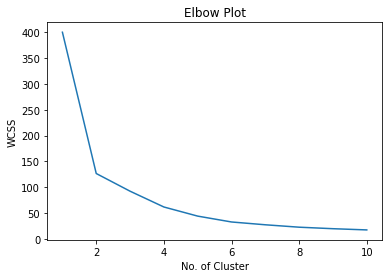

In [ ]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    km.fit(X_sc)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans=kmeans.fit_predict(X_sc)
plt.scatter(X_sc[:,0],X_sc[:,1],c=y_kmeans,cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=200,marker='X')
plt.show()

In [32]:
print(y_kmeans)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0]


In [33]:
# Cluster centeriods
print (kmeans.cluster_centers_)

[[ 0.96628215  0.91732732]
 [-0.74395174 -0.70626086]]


In [34]:
# assign the y_kmeans to a new column in the dataset
df_dh['kmean_prid']= y_kmeans
df_dh

,height,weight,target,type,kmean_prid
0,27.0,71.0,0.0,dog,1
1,27.0,92.0,0.0,dog,1
2,32.0,47.0,0.0,dog,1
3,30.0,90.0,0.0,dog,1
4,28.0,91.0,0.0,dog,1
...,...,...,...,...,...
195,55.0,140.0,1.0,horse,0
196,82.0,179.0,1.0,horse,0
197,46.0,132.0,1.0,horse,0
198,56.0,89.0,1.0,horse,1


### Plot the clusters including the centroid for each of the clusters as defined by K-Means

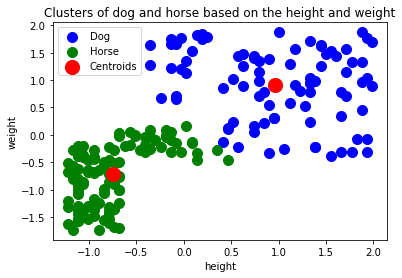

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].scatter(df_dh['height'],df_dh['weight'],c=df_dh['type'].map({'Dog':0,'Horse':1}))
ax[0].set_title('Actual')
ax[1].scatter(df_dh['height'],df_dh['weight'],c=y_kmeans)
ax[1].set_title('KMeans')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
df_dh['type']=df_dh['type'].map({'Dog':0,'Horse':1})

In [ ]:
# Calculate the number of correct predictions
(df_dh['type'] == df_dh['kmean_prid']).value_counts()

True     187
False     13
dtype: int64

In [ ]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_dh['type'], df_dh['kmean_prid'])*100

93.5

# Seattle Weather KMeans Challenge

In [15]:
df_sea = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/seattle_weather_1948-2017.csv")
X_sea = df_sea[['tmax', 'tmin']]
df_sea.head()

,ds,prcp,tmax,tmin,rain
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [ ]:
sc_sea=StandardScaler()
X_sea_sc=sc_sea.fit_transform(X_sea)

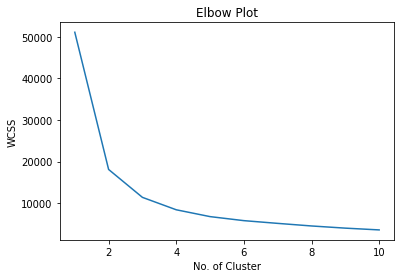

In [ ]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    km.fit(X_sea_sc)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss,marker='o')
plt.show()

In [ ]:
kmeans_sea=KMeans(n_clusters=2, random_state=42, n_init=10)
y_sea_kmeans=kmeans_sea.fit_predict(X_sea_sc)
plt.scatter(X_sea_sc[:,0],X_sea_sc[:,1],c=y_sea_kmeans,cmap='coolwarm')
plt.scatter(kmeans_sea.cluster_centers_[:,0],kmeans_sea.cluster_centers_[:,1],s=200,marker='X')
plt.show()

In [19]:
print(y_sea_kmeans)

[1 1 1 ... 1 1 1]


In [20]:
# assign the y_kmeans to a new column
df_sea['kmean_sea_prid']= y_sea_kmeans
df_sea

,ds,prcp,tmax,tmin,rain,kmean_sea_prid
0,1948-01-01,0.47,51,42,True,1
1,1948-01-02,0.59,45,36,True,1
2,1948-01-03,0.42,45,35,True,1
3,1948-01-04,0.31,45,34,True,1
4,1948-01-05,0.17,45,32,True,1
...,...,...,...,...,...,...
25546,2017-12-10,0.00,49,34,False,1
25547,2017-12-11,0.00,49,29,False,1
25548,2017-12-12,0.00,46,32,False,1
25549,2017-12-13,0.00,48,34,False,1


In [21]:
# replace True with 1 and False with 0 to help us caluclate the Accuracy Score
df_sea['rain'] = df_sea['rain'].map({True:1, False:0})

In [ ]:
(df_sea['rain']==df_sea['kmean_sea_prid']).value_counts()

True     16266
False     9285
dtype: int64

In [23]:
df_sea.dropna(subset = ['rain'], inplace=True)

In [24]:
df_sea['rain'].isna().sum()

0

### Plot the clusters including the centroid for each of the clusters as defined by K-Means

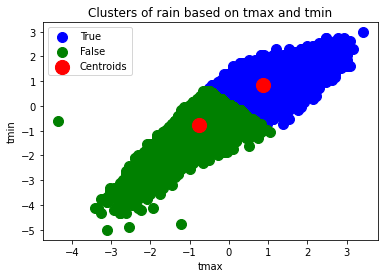

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_sea_sc[:,0],X_sea_sc[:,1],c=y_sea_kmeans,cmap='coolwarm')
plt.scatter(kmeans_sea.cluster_centers_[:,0],kmeans_sea.cluster_centers_[:,1],s=200,marker='X')
plt.title('Seattle Weather Clusters')
plt.show()

In [ ]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_sea['rain'], df_sea['kmean_sea_prid'])*100

63.66838891498357

# Random Blob KMeans Challenge

- You dont have true labels for this data so this is truly an unsupervised dataset
- The blobs are randomly generated every time you run the cell and their characteristics are:
    - 2000-4000 data points
    - 10-30 blobs created

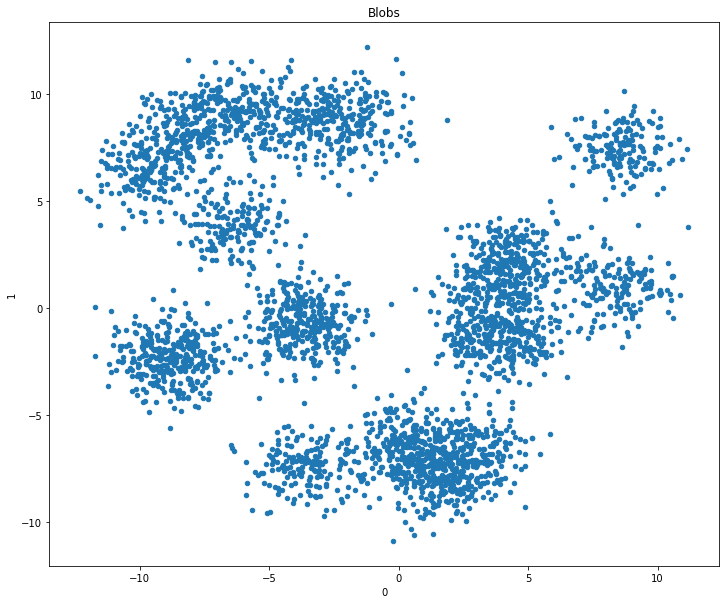

In [ ]:
X_blob,y_blob=make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)
df_blob=pd.DataFrame(X_blob,columns=['Feature1','Feature2'])
plt.scatter(df_blob['Feature1'],df_blob['Feature2'])
plt.show()

In [40]:
# Scale Data
sc_blb = StandardScaler()
# Fit & transform data.
X_blb_sc = sc.fit_transform(df_blob)

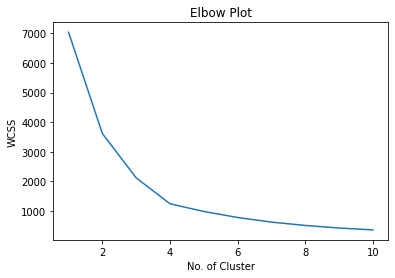

In [ ]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    km.fit(X_blb_sc)
    wcss.append(km.inertia_)
plt.plot(range(1,11),wcss,marker='o')
plt.show()

In [ ]:
kmeans_blb=KMeans(n_clusters=4, random_state=42, n_init=10)
y_blb_kmeans=kmeans_blb.fit_predict(X_blb_sc)
plt.scatter(X_blb_sc[:,0],X_blb_sc[:,1],c=y_blb_kmeans,cmap='tab10')
plt.scatter(kmeans_blb.cluster_centers_[:,0],kmeans_blb.cluster_centers_[:,1],s=200,marker='X')
plt.show()

In [57]:
print(y_blb_kmeans)

[2 0 2 ... 1 3 3]


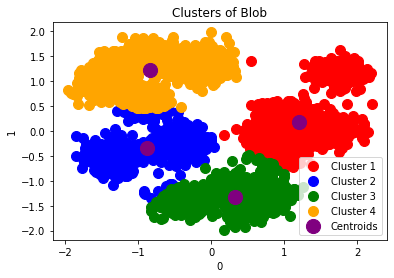

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_blb_sc[:,0],X_blb_sc[:,1],c=y_blb_kmeans,cmap='tab10')
plt.scatter(kmeans_blb.cluster_centers_[:,0],kmeans_blb.cluster_centers_[:,1],s=250,marker='X')
plt.title('Blob Clusters with Centroids')
plt.show()